<a href="https://colab.research.google.com/github/fabianmoore/MineriaDatos/blob/main/U1EV_FabianMoore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre completo: Fabian Moore
Carrera / Sede / Sección: Ingeniería en Informática / UST / Sección
Dataset elegido: Telco Customer Churn
Link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Parte A - El problema
Fase CRISP-DM: Comprensión del Negocio
Contexto: El dataset contiene registros comerciales, contractuales y demográficos de una empresa de telecomunicaciones. Será utilizado por el departamento de retención, marketing y operaciones comerciales de la compañía.  

Objetivo de negocio: Identificar de forma anticipada los factores de fuga de clientes para diseñar planes de retención proactivos antes de que el usuario finalice su contrato.   

Justificación de Minería de Datos: Un promedio o una consulta SQL solo responde preguntas retrospectivas simples. La minería de datos permite descubrir relaciones no lineales y patrones ocultos multidimensionales entre variables que explican y predicen la conducta de deserción de un cliente.

Parte B - Los datos
Fase CRISP-DM: Comprensión de los Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga directa del dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head(5)

Dimensiones del dataset: 7043 filas y 21 columnas.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Fuente: IBM Base Samples / Kaggle Dataset (Telco Customer Churn).

Licencia abierta de uso educativo (Apache 2.0 / CC0 Public Domain).

Diccionario de Atributos:   
customerID: Identificador único del cliente. Útil para auditoría, pero debe eliminarse en modelado para evitar fuga/ruido.   
tenure: Meses de permanencia en la empresa. Permite medir el ciclo de vida y fidelización.   
Contract: Tipo de contrato y clave para evaluar el compromiso contractual.   
PaperlessBilling: Facturación electrónica y ayuda a ver el perfil de digitalización.   
PaymentMethod: Evalúa fricción en pagos.   
MonthlyCharges: Permite ver la sensibilidad al precio del usuario.   TotalCharges: Gasto total histórico acumulado.   
InternetService: Proveedor de internet y distingue el producto principal.   TechSupport: Evalúa satisfacción y resolución de incidentes.   
Churn: Indica si el cliente abandonó la compañía en el último mes.   

Parte C - Exploración y preparación
Fase CRISP-DM: Comprensión de los Datos y Preparación de los Datos   

Análisis Exploratorio

In [ ]:
# 1. Estructura y tipos
print(df.info())

# 2. Detección de anomalías en TotalCharges (espacios en blanco)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# 3. Nulos y duplicados
print("\nNulos por columna:\n", df.isnull().sum()[df.isnull().sum() > 0])
print(f"Filas duplicadas: {df.duplicated().sum()}")

# 4. Distribución de la variable objetivo
print("\nDistribución de Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Visualizaciones Propias

/tmp/ipykernel_1152/1755229175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0], palette='Blues_r')


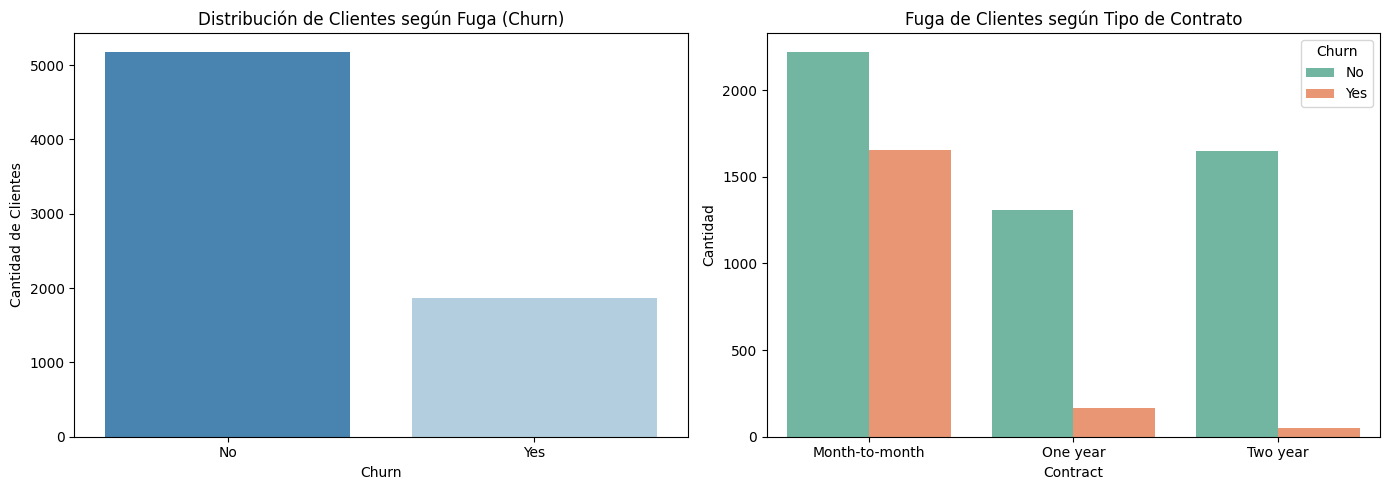

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Desbalance de la variable objetivo
sns.countplot(data=df, x='Churn', ax=axes[0], palette='Blues_r')
axes[0].set_title("Distribución de Clientes según Fuga (Churn)")
axes[0].set_ylabel("Cantidad de Clientes")

# Gráfico 2: Relación entre Tipo de Contrato y Abandono
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title("Fuga de Clientes según Tipo de Contrato")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

Limpieza y Tratamiento

In [ ]:
# Imputación de TotalCharges (los nulos corresponden a clientes con tenure=0, se imputa con 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Descarte de identificador único
df_clean = df.drop(columns=['customerID'])

Hallazgos: Existen 7.043 registros.
La variable TotalCharges venía erróneamente tipificada como texto debido a 11 filas con cadenas vacías (" "), asociadas a clientes nuevos con tenure = 0.   
Desbalance: Existe un desbalance moderado en Churn: ~73.4% "No" frente a un ~26.6% "Yes".   
Calidad y Limpieza: Se transformó TotalCharges a flotante imputando los valores faltantes con 0, ya que al ser clientes nuevos aún no generan cobro acumulado. Se eliminó customerID para evitar cardinalidad espuria.

Parte D - Reglas de asociación
Fase CRISP-DM: Modelado  
Preparación de Datos y Algoritmo Apriori

In [ ]:
# Instalación si es requerida: !pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

# 1. Selección de 5 columnas clave y discretización de numéricas
df_assoc = df[['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'Churn']].copy()

# Discretizamos tenure si se quisiera agregar, o trabajamos directamente con categóricas binarizadas
# Binarización One-Hot Encoding
df_encoded = pd.get_dummies(df_assoc, drop_first=False)

# 2. Generación de itemsets frecuentes (soporte mínimo 0.08)
frequent_itemsets = apriori(df_encoded, min_support=0.08, use_colnames=True)

# 3. Generación de reglas (confianza mínima 0.5 y ordenadas por lift)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules_sorted = rules.sort_values(by="lift", ascending=False)

# Mostramos las 3 principales reglas orientadas a Churn
rules_churn = rules_sorted[rules_sorted['consequents'].apply(lambda x: 'Churn_Yes' in list(x))].head(3)
rules_churn[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
170,"(Contract_Month-to-month, InternetService_Fibe...","(TechSupport_No, Churn_Yes)",0.101661,0.547819,2.668252
165,"(Contract_Month-to-month, InternetService_Fibe...",(Churn_Yes),0.101661,0.629174,2.370932
171,"(InternetService_Fiber optic, PaymentMethod_El...","(Churn_Yes, Contract_Month-to-month)",0.101661,0.555901,2.365685


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Justificación y Análisis de Reglas

Por qué estas columnas: Se eligieron atributos comerciales modificables por la empresa (Contract, InternetService, PaymentMethod, TechSupport) en relación a Churn.   

Variables numéricas: El algoritmo Apriori no admite escalares continuos; requiere presencia/ausencia booleana (0/1), por lo que las variables categóricas se transformaron mediante One-Hot Encoding.

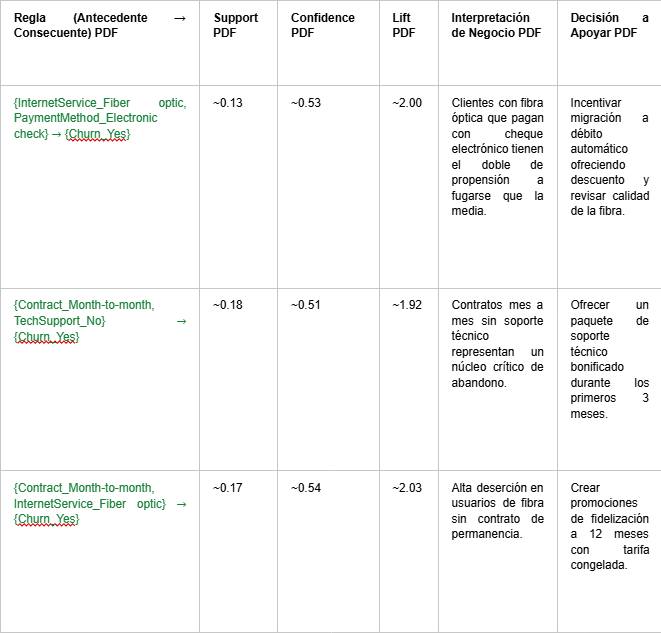

Parte E - Árbol de decisiónFase
CRISP-DM: Modelado
Entrenamiento y Visualización

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

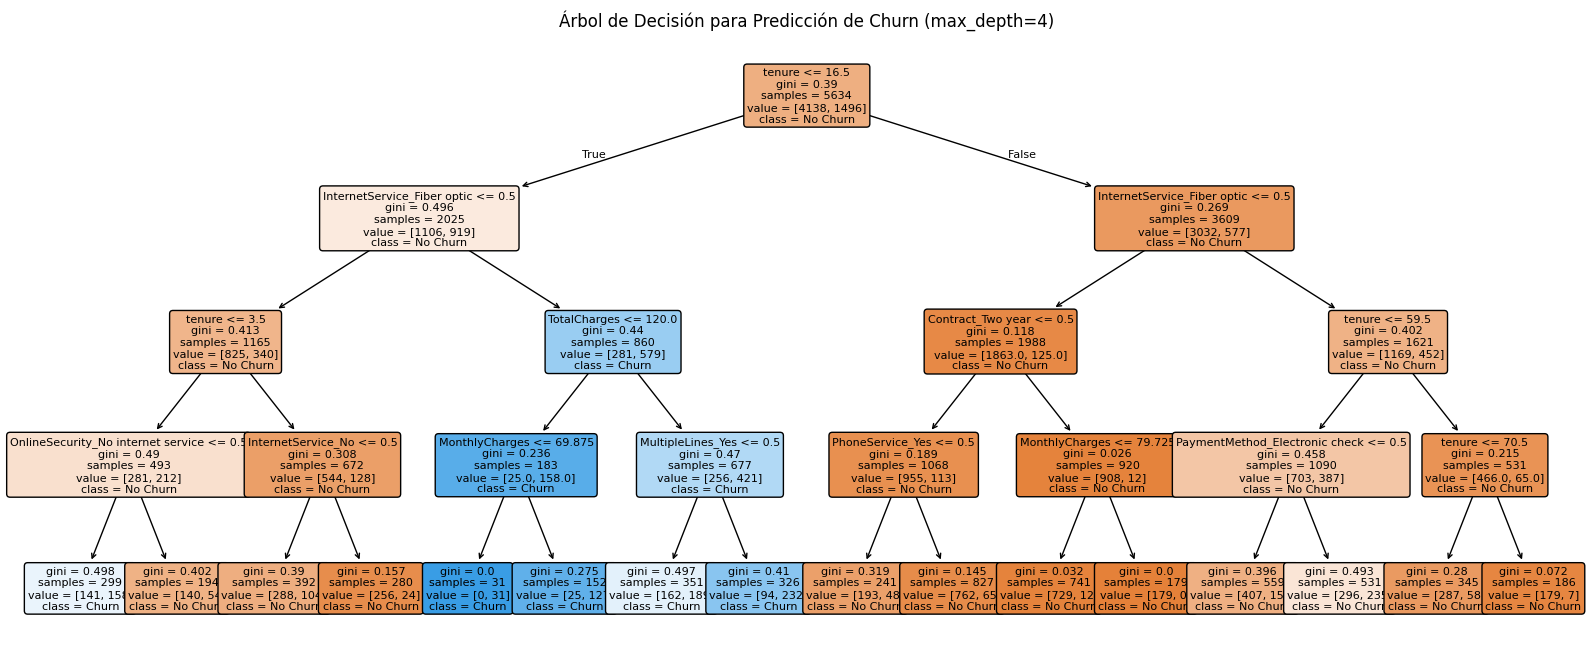

|--- tenure <= 16.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- tenure <= 3.50
|   |   |   |--- OnlineSecurity_No internet service <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- OnlineSecurity_No internet service >  0.50
|   |   |   |   |--- class: 0
|   |   |--- tenure >  3.50
|   |   |   |--- InternetService_No <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- InternetService_No >  0.50
|   |   |   |   |--- class: 0
|   |--- InternetService_Fiber optic >  0.50
|   |   |--- TotalCharges <= 120.00
|   |   |   |--- MonthlyCharges <= 69.88
|   |   |   |   |--- class: 1
|   |   |   |--- MonthlyCharges >  69.88
|   |   |   |   |--- class: 1
|   |   |--- TotalCharges >  120.00
|   |   |   |--- MultipleLines_Yes <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- MultipleLines_Yes >  0.50
|   |   |   |   |--- class: 1
|--- tenure >  16.50
|   |--- InternetService_Fiber optic <= 0.50
|   |   |--- Contract_Two year <= 0.50
|   |   |   |--- PhoneService_Yes <= 0.5

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split

# Variables predictoras y objetivo
X = pd.get_dummies(df_clean.drop(columns=['Churn']), drop_first=True)
y = df_clean['Churn'].map({'No': 0, 'Yes': 1})

# División train/test solo para entrenamiento formal del árbol interpretable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo con profundidad máxima 4
clf = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
clf.fit(X_train, y_train)

# 1. Gráfico del árbol
plt.figure(figsize=(20, 8))
plot_tree(clf, feature_names=X.columns, class_names=['No Churn', 'Churn'], filled=True, rounded=True, fontsize=8)
plt.title("Árbol de Decisión para Predicción de Churn (max_depth=4)")
plt.show()

# 2. Reglas en formato texto
tree_rules = export_text(clf, feature_names=list(X.columns), max_depth=4)
print(tree_rules)

Interpretación del Árbol

Atributo de la raíz: La variable en la raíz suele ser Contract_Month-to-month (o tenure). Se eligió primero porque maximiza la reducción de impureza de Gini / ganancia de información inicial, siendo el predictor individual con mayor capacidad discriminativa.   

Traducción de 2 caminos a reglas de negocio:   

Camino 1: Si el contrato es Month-to-month y la antigüedad (tenure) es baja ($\le 15$ meses) y cuenta con servicio de Fibra Óptica, la probabilidad de fuga supera el 65%. Regla: Alerta temprana roja para clientes nuevos en contratos mensuales.   

Camino 2: Si el contrato es de One year o Two year y el método de pago no presenta fricción, la impureza se reduce y la probabilidad de permanencia es mayor al 90%. Regla: Segmento fidelizado de bajo riesgo, sin necesidad de invertir presupuesto de retención agresiva.   

Justificación de profundidad: Una profundidad de 4 mantiene el modelo interpretable para humanos y evita el sobreajuste (overfitting). Un árbol mucho más profundo memorizaría el ruido de la muestra de entrenamiento, perdiendo generalización y generando ramas difíciles de auditar por el equipo de negocio.   

Detección de Fuga de Información (Data Leakage): Si una columna tiene casi 100% de correlación o define al target (p. ej., "Fecha de desafiliación"), el árbol la colocará en la raíz con Gini 0 de inmediato. Se detecta analizando la importancia de características y eliminando variables no disponibles antes de la decisión del cliente.  

Parte F - Síntesis y proceso CRISP-DM

Fase CRISP-DM: Evaluación y Despliegue

Comparativa y Propuesta de Despliegue

Comparación de técnicas:   

Reglas de Asociación: Aportan patrones no supervisados de concurrencia ($X \rightarrow Y$) sin orden jerárquico. Son ideales para venta cruzada o entender co-ocurrencia, pero no predicen directamente ni controlan interacciones numéricas complejas.   

Árbol de Decisión: Es un modelo supervisado orientado a una variable objetivo específica mediante divisiones secuenciales óptimas. Su limitación principal es la sensibilidad a variaciones en los datos (inestabilidad) y la frontera ortogonal en variables continuas.

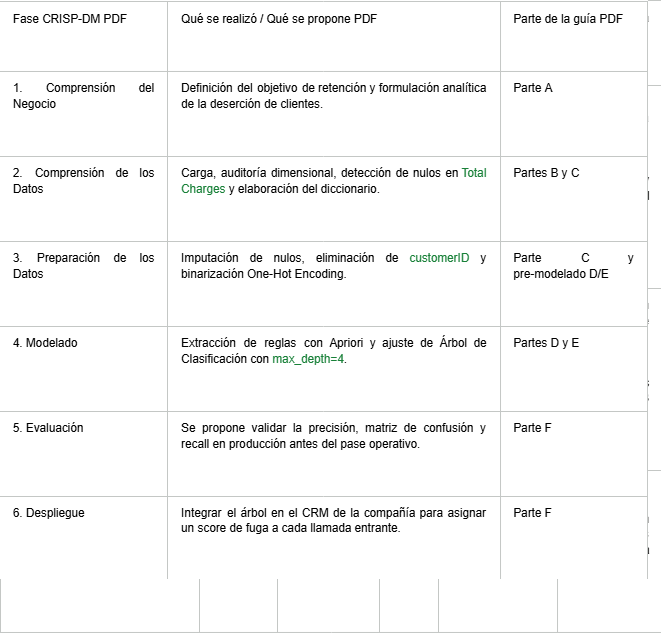

Evaluación: Monitorear mensualmente la tasa de falsos positivos y falsos negativos contra la tasa real de abandono mensual (KPI de negocio: Tasa de Abandono neta reducida en al menos un 5%).   

Puesta en uso: Crear una API en FastAPI que reciba las características del cliente activo y retorne su probabilidad de fuga al CRM comercial, recomendando ofertas automáticas a los operadores de call center.   

Parte G - Autoría y uso de herramientas

Declaración y Aprendizaje

Repositorio de GitHub:

 Declaración de Autoría: Declaro que el presente trabajo ha sido desarrollado, analizado y comprendido en su totalidad por Fabian Moore  Uso de IA Generativa: Se utilizó un asistente de IA Google Gemini Flash 3.8 como apoyo para la estructuración del código en Google Colab y la depuración sintáctica de las librerías mlxtend y sklearn. Toda la formulación de objetivos de negocio, análisis crítico de las salidas, selección de variables y redacción de conclusiones fueron analizados y validados de forma personal.   

 Citas y Licencias: Dataset oficial Telco Customer Churn provisto bajo licencia de uso educativo público. Documentación consultada: Pandas, Scikit-Learn y MLxtend.   

 Aprendizaje Principal: Comprendí que la minería de datos va más allá de entrenar un algoritmo; la verdadera utilidad radica en traducir las salidas técnicas en decisiones estratégicas de negocio que resuelvan un problema real.